In [1]:
#from universe import *
#from halo_fit import *
#from weight import *
#from pn_2d import *
from cmb import *
#import vegas
#from flat_map import *
from scipy.special import jv,jvp,comb
from math import factorial
from hankel import HankelTransform as hnkl
#from patchy_penalty import *
import multiprocessing as mp
ncpu = mp.cpu_count()
def rgb_to_mpl_color(r, g, b): return (r / 255, g / 255, b / 255)

import sys; sys.path.append('../../Downloads/')
from act_patchy import coulton_measurement,mean_field,corrmat

# cmb lensing power spectrum
#u = UnivPlanck15()
#halofit = Halofit(u, save=False)
#w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
#p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False)
# number of pixels for the flat map
#nX = 1024 #1200
#nY = 1024 #1200
# map dimensions in degrees
#sizeX = 2.
#sizeY = 2.
# basic map object
#baseMap = FlatMap(nX=nX, nY=nY, sizeX=sizeX*np.pi/180., sizeY=sizeY*np.pi/180.)
# multipoles to include in the lensing reconstruction
lMin = 30.; lMax = 1e4
# Adjust the lMin and lMax to the assumptions of the analysis
# CMB S3 specs
cmb = CMB(beam=1.4, noise=12., lMin=lMin, lMaxT=lMax, lMaxP=lMax, fg=True, atm=False)
# Total power spectrum, for the lens reconstruction
forCtotal = lambda l: 1./cmb.ftotalTT(l)
# reinterpolate: gain factor 10 in speed
L = np.logspace(1., np.log10(2.*lMax), 5001)
F = np.array(list(map(forCtotal, L)))
cmb.fCinvtotal = interp1d(L, F, kind='linear', bounds_error=False, fill_value=0.)

import matplotlib
from matplotlib.pyplot import rc
import matplotlib.font_manager

rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
rc('mathtext', **{'fontset':'cm'})
rc('text', usetex=True)
rc('legend',**{'fontsize':'18'})

matplotlib.rcParams['axes.linewidth'] = 3
matplotlib.rcParams['axes.labelsize'] = 30
matplotlib.rcParams['xtick.labelsize'] = 25 
matplotlib.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.minor.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 3
matplotlib.rcParams['ytick.major.width'] = 3
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

/home/noah/Berkeley/FlatSkyQE/basic_functions.py:98: RuntimeWarning: divide by zero encountered in divide
  try: return x/y
/home/noah/Berkeley/FlatSkyQE/cmb.py:127: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/home/noah/Berkeley/FlatSkyQE/cmb.py:135: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl
/home/noah/Berkeley/FlatSkyQE/cmb.py:149: RuntimeWarning: invalid value encountered in multiply
  data[:,1] *= self.fdl_to_cl(data[:,0]) # convert Dl to Cl


# Lensed temperature power spectrum.

\begin{equation}
\begin{aligned}
    C^{TT}_\ell
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \int q\,dq\,\,
    e^{-q^2\mathcal{B}(R)}
    C^0_q
    \int \frac{d\theta}{2\pi}
    e^{-q^2\mathcal{A}(R)\cos^2(\theta)} e^{iqR\cos(\theta)}
    \\
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \sum_{n=0}^\infty
    \frac{\big[\mathcal{A}(R)\big]^n}{n!R^{2n}}
    \int dq\,\,
    e^{-q^2\mathcal{B}(R)}
    C^0_q q^{2n+1}
    \frac{d^{2n} J_0(qR)}{dq^{2n}}
    \\
    &=
    \int R\,dR\,\,
    J_0(\ell R)
    \sum_{n=0}^\infty
    \frac{\big[\mathcal{A}(R)\big]^n}{n!R^{2n}}
    \int dq\,\,J_0(qR)
    \frac{d^{2n}}{dq^{2n}}[
    e^{-q^2\mathcal{B}(R)}
    C^0_q q^{2n+1}]
\end{aligned}
\end{equation}
where I defined
\begin{equation}
\begin{aligned}
    \mathcal{A}(R) 
    &\equiv 
    \int \frac{\ell^3 d\ell}{2\pi} J_2(\ell R)
    C^{\phi\phi}_\ell
    \\
    \mathcal{B}(R) 
    &\equiv 
    \int \frac{\ell^3 d\ell}{2\pi} 
    \bigg[
    \frac{1}{2}-\frac{J_1(\ell R)}{\ell R}
    \bigg]
    C^{\phi\phi}_\ell
\end{aligned}
\end{equation}



$$F(x,y) = \int\frac{d\theta}{2\pi}e^{x \cos^2\theta + i y \cos\theta}$$

$$F(x,y) = \sum_{mn} \frac{1}{m!n!} x^m y^n \frac{\partial^{m+n} F(x,y)}{\partial x^m \partial y^n}\Bigg|_{x=y=0}$$

$$\frac{\partial^{m+n} F(x,y)}{\partial x^m \partial y^n}\Bigg|_{x=y=0} = i^n \int \frac{d\theta}{2\pi} \cos^{2m+n}\theta$$

In [2]:
# compute A(R) and B(R)
nr = 1000
Cpp = lambda l: 4*p2d_cmblens.fPinterp(l)/l**4
def fA(R,nl=1000000): 
    l = np.logspace(np.log10(1e-2),np.log10(4.9e4),nl)
    return simps(Cpp(l)*l**3*jv(2,l*R)/(2*np.pi),l)
def fB(R,nl=1000000): 
    l = np.logspace(np.log10(1e-2),np.log10(4.9e4),nl)
    return simps(Cpp(l)*l**3*(0.5-jv(1,l*R)/(l*R))/(2*np.pi),l)
if False:
    R = np.logspace(np.log10(0.1/60*np.pi/180),np.log10(30),nr) # radians
    A = np.array([fA(r) for r in R])
    B = np.array([fB(r) for r in R])
    np.savetxt('RAB.txt',np.array([R,A,B]).T)
else:
    R,A,B = np.loadtxt('RAB.txt').T
RR = np.logspace(np.log10(0.1/60*np.pi/180),3,int(3e3))
A  = interp1d(R,A,bounds_error=False,fill_value=(0.,0.))(RR)
B  = interp1d(R,B,bounds_error=False,fill_value=(0.,B[-1]))(RR)
R  = RR

Text(0.5, 0, '$R$ [arcmin]')

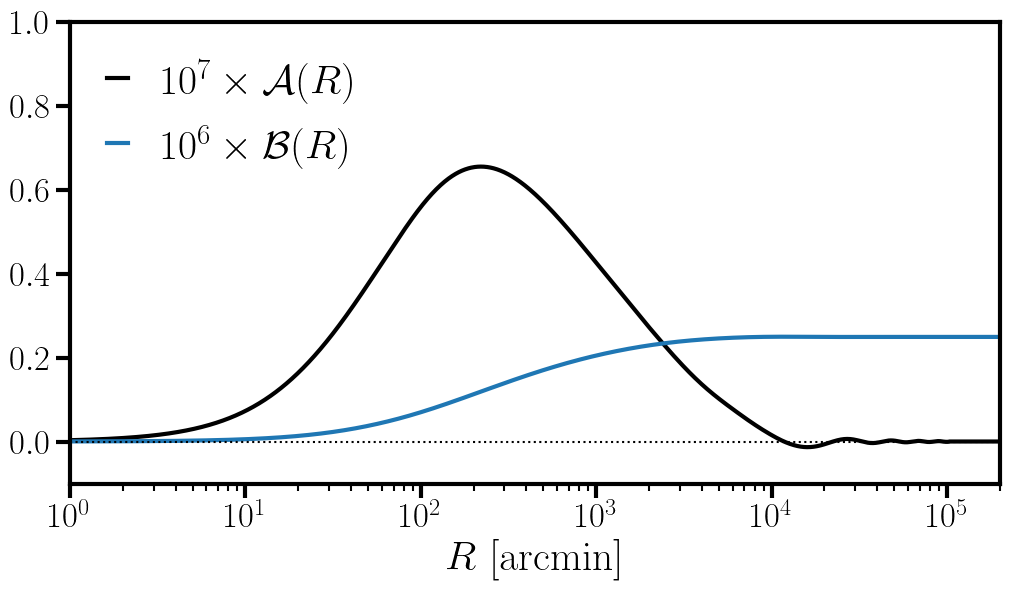

In [3]:
# and plot them
plt.figure(figsize=(12,6))
plt.plot(R*180/np.pi*60,1e7*A,lw=3,label=r'$10^7\times\mathcal{A}(R)$',c='k')
plt.plot(R*180/np.pi*60,1e6*B,lw=3,label=r'$10^6\times\mathcal{B}(R)$',c='C0')
plt.xscale('log')
plt.yscale('linear')
plt.xlim(1,2e5)
plt.ylim(-0.1,1)
plt.axhline(y=0,c='k',ls='dotted')
plt.legend(loc='upper left',frameon=False,fontsize=30,handlelength=0.5)
plt.xlabel(r'$R$ [arcmin]')

In [4]:
qmax       = 1e4
nq         = 10000
nmax       = 20
def qintegrand(q,nmax=10):
    result = jv(1,q*R)
    for n in range(1,nmax+1): result += (q**2*A)**n*A*jvp(1,q*R,n)/float(factorial(n))
    return result*q**2*np.exp(-q**2*B)*cmb.funlensedTT(q)
Q          = np.logspace(np.log10(2),np.log10(qmax),nq)
Rintegrand = np.array([qintegrand(q) for q in Q])
Rintegrand = simps(Rintegrand,Q,axis=0)
Rsparse          = np.logspace(np.log10(0.5),np.log10(R[-1]),200)
Rintegrand_highR = hnkl(nu=1,h=1e-5).transform(lambda l: l*cmb.funlensedTT(l)*np.exp(-l**2*B[-1]),k=Rsparse,ret_err=False)
Rintegrand[np.where(R>1)] = np.interp(R[np.where(R>1)],Rsparse,Rintegrand_highR)   

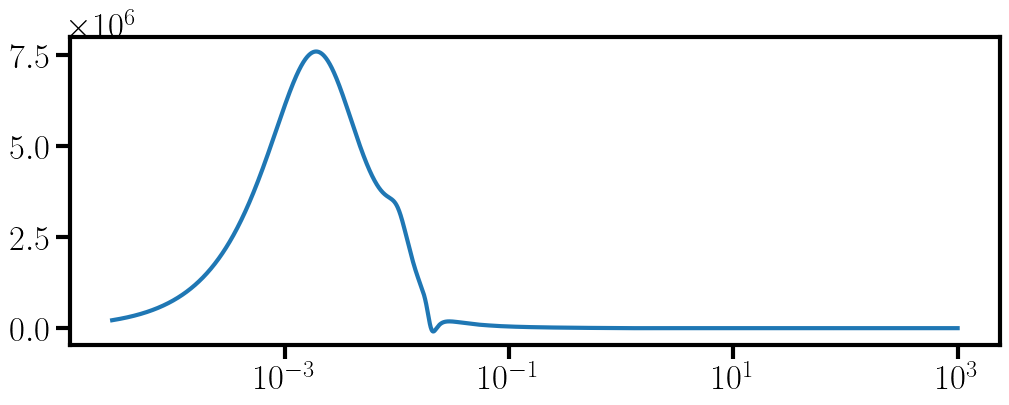

In [5]:
plt.figure(figsize=(12,4))
plt.semilogx(R,Rintegrand,lw=3)

In [6]:
l = np.logspace(np.log10(2),np.log10(1e4),5000)
K = hnkl(nu=1,h=1e-3).transform(lambda r: np.interp(r,R,Rintegrand),k=l,ret_err=False)/l

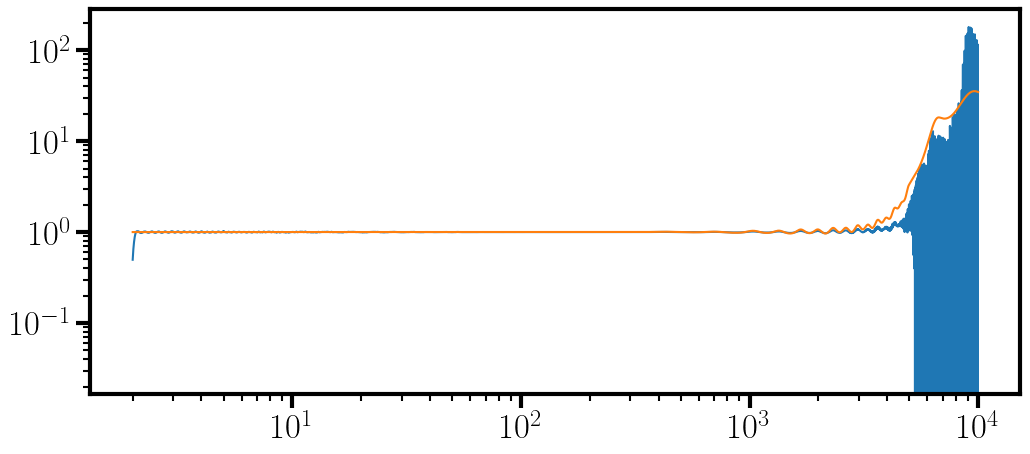

In [10]:
plt.figure(figsize=(12,5))
plt.loglog(l,K/cmb.funlensedTT(l))
plt.loglog(l,cmb.flensedTT(l)/cmb.funlensedTT(l))

In [5]:
# Compute A(R) and B(R)
Cpp = lambda l: 4*p2d_cmblens.fPinterp(l)/l**4
RA  = np.logspace(np.log10(0.1/60*np.pi/180),np.log10(30),100)
A   = hnkl(nu=2,h=1e-5).transform(lambda l: l**2*Cpp(l)/(2*np.pi),k=RA,ret_err=False)
RB  = np.array([0.1/60*np.pi/180,1/60*np.pi/180] + np.logspace(np.log10(2/60*np.pi/180),np.log10(30),25).tolist())
B   = hnkl(nu=1,h=4e-7).transform(lambda l: l*Cpp(l)/(2*np.pi),k=RB,ret_err=False)/RB
B   = B[0] - B
R   = np.logspace(np.log10(max(RA[0],RB[0])), np.log10(min(RA[-1],RB[-1])),500)
A,B = np.interp(R,RA,A),np.interp(R,RB,B)

Text(0.5, 0, '$R$ [arcmin]')

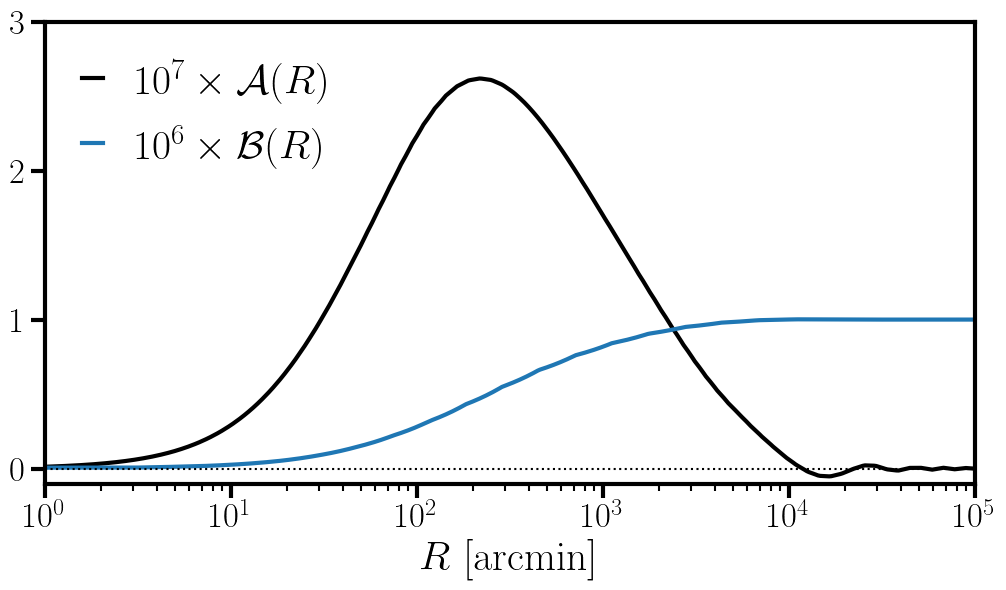

In [14]:
# and plot them
plt.figure(figsize=(12,6))
plt.plot(R*180/np.pi*60,1e7*A,lw=3,label=r'$10^7\times\mathcal{A}(R)$',c='k')
plt.plot(R*180/np.pi*60,1e6*B,lw=3,label=r'$10^6\times\mathcal{B}(R)$',c='C0')
plt.xscale('log')
plt.yscale('linear')
plt.xlim(1,1e5)
plt.ylim(-0.1,3)
plt.axhline(y=0,c='k',ls='dotted')
plt.legend(loc='upper left',frameon=False,fontsize=30,handlelength=0.5)
plt.xlabel(r'$R$ [arcmin]')

In [19]:
def psum(nmax=2,qmax=2e4,nq=10000):
    q     = np.logspace(np.log10(2.),np.log10(qmax),nq)
    QQ,RR = np.meshgrid(q,R,indexing='ij')
    _ ,AA = np.meshgrid(q,A,indexing='ij')
    _ ,BB = np.meshgrid(q,B,indexing='ij')
    res   = np.zeros_like(QQ)
    for n in range(nmax+1): res += (QQ**2*AA)**n*jvp(0,QQ*RR,2*n)/factorial(n)
    res  *= QQ*cmb.funlensedTT(QQ)*np.exp(-QQ**2*BB)
    return simps(res,x=q,axis=0)
    
I   = psum(nmax=4,qmax=2e4,nq=int(1e5))
L   = np.logspace(np.log10(2),np.log10(14000),5000)
CTT = hnkl(nu=0,h=1e-1).transform(lambda r: np.interp(r,R,I),k=L,ret_err=False)

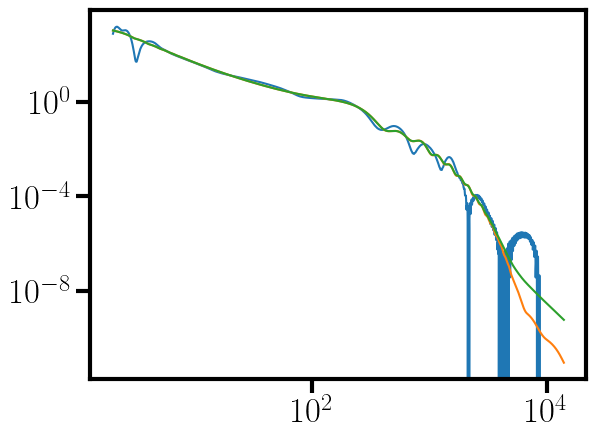

In [21]:
plt.loglog(L,CTT)
plt.loglog(L,cmb.funlensedTT(L))
plt.loglog(L,cmb.flensedTT(L))

# Contour integral

In [ ]:
Lambda = 0.5
k      = 1
zr_min, zr_max = -5,5
zi_min, zi_max = -5,5
fig,ax = plt.subplots(1,1,figsize=(10/1.2,8/1.2))
ticks  = [0,1,2,3,4,5,6,7,8]
zr = np.linspace(zr_min,zr_max,500)
zi = np.linspace(zi_min,zi_max,500)
ZR,ZI = np.meshgrid(zr,zi)
Z = ZR+ZI*1.j
F = np.tanh(k*Z)*(1 + np.tanh(k*Z*np.tanh(k*Z) - k*Lambda))/2.
levels = np.linspace(ticks[0],ticks[-1],100,endpoint=True)
contour = ax.contourf(ZR,ZI,np.abs(F),cmap='hot',levels=levels,extend='max')
plt.colorbar(contour, ticks=ticks)
def draw_leftside_arrow(ls='-',c='w',theta=0.,lw=3,delt=0.4):
    R = np.array([[np.cos(theta),np.sin(theta)],[-1.*np.sin(theta),np.cos(theta)]])
    L = np.dot(R,np.array([2*zr_min,0.]))
    ax.plot([L[0],0],[L[1],0],c=c,ls=ls,lw=lw)
    p1 = np.dot(R,np.array([zr_min/2,0.]))
    p2 = np.dot(R,np.array([zr_min/2-delt,delt]))
    p3 = np.dot(R,np.array([zr_min/2-delt,-1.*delt]))
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]],c=c,ls='-',lw=lw)
    ax.plot([p1[0],p3[0]],[p1[1],p3[1]],c=c,ls='-',lw=lw)
draw_leftside_arrow()
draw_leftside_arrow(theta=-np.pi/6,ls='--')
def draw_rightside_arrow(ls='-',c='w',theta=0.,lw=3,delt=0.35):
    R = np.array([[np.cos(theta),np.sin(theta)],[-1.*np.sin(theta),np.cos(theta)]])
    L = np.dot(R,np.array([2*zr_max,0.]))
    ax.plot([L[0],0],[L[1],0],c=c,ls=ls,lw=lw)
    p1 = np.dot(R,np.array([zr_max/2,0.]))
    p2 = np.dot(R,np.array([zr_max/2-delt,delt]))
    p3 = np.dot(R,np.array([zr_max/2-delt,-1.*delt]))
    ax.plot([p1[0],p2[0]],[p1[1],p2[1]],c=c,ls='-',lw=lw)
    ax.plot([p1[0],p3[0]],[p1[1],p3[1]],c=c,ls='-',lw=lw)
draw_rightside_arrow()
draw_rightside_arrow(theta=np.pi/6,ls='--')
ax.text(2.5,-0.8,r'$\boldsymbol{\theta = \epsilon/\omega}$',color='w')
ax.text(-4,3,r'$\boldsymbol{|f^{k}_{\Lambda}(z)|}$',color='w',fontsize=35)
ax.set_xlabel(r'$k\,\,\text{Re}[z]$')
ax.set_ylabel(r'$\text{Im}[z]$')
ax.set_xlim(zr_min, zr_max)
ax.set_ylim(zi_min, zi_max)
ax.set_yticks([-3*np.pi/2+np.pi*n for n in range(4)]+[0],[r'$-\frac{3\pi}{2k}$',r'$-\frac{\pi}{2k}$',r'$\frac{\pi}{2k}$',r'$\frac{3\pi}{2k}$',r'$0$'])
plt.savefig('../../Downloads/contour_plot.pdf',bbox_inches='tight')

# Raw response functions

In [2]:
def fk(l,L,theta):
    """linear response to kappa"""
    Lml = (L**2+l**2-2*L*l*np.cos(theta))**0.5
    res = L*l*np.cos(theta)*cmb.flensedTT(l)
    res+= L*(L-l*np.cos(theta))*cmb.flensedTT(Lml)
    return np.nan_to_num(2*res/L**2)
def ft(l,L,theta):
    """linear response to patchy screening"""
    Lml = (L**2+l**2-2*L*l*np.cos(theta))**0.5
    res = cmb.flensedTT(l) + cmb.flensedTT(Lml)
    return -1.*res
def fs(l,L,theta): return 1e-5
def fancyRxy(L,fx,fy,lmax=10e3,ntheta=300):
    theta = np.linspace(0,2*np.pi,ntheta)
    l     = np.linspace(1,lmax,int(lmax))
    res   = np.zeros_like(theta)
    for i in range(ntheta):
        Lml    = (L**2+l**2-2*L*l*np.cos(theta[i]))**0.5
        intg   = (Lml<lmax)*fx(l,L,theta[i])*fy(l,L,theta[i])*cmb.fCinvtotal(l)*cmb.fCinvtotal(Lml)*l/(2*np.pi)**2/2
        res[i] = np.trapz(intg,l)
    return np.trapz(res,theta)
def getAll_fancyRxy(L,lmax=2e4,ntheta=500):
    res = [fancyRxy(L,ft,ft,lmax=lmax,ntheta=ntheta),
           fancyRxy(L,fk,fk,lmax=lmax,ntheta=ntheta),
           fancyRxy(L,fs,fs,lmax=lmax,ntheta=ntheta),
           fancyRxy(L,ft,fk,lmax=lmax,ntheta=ntheta),
           fancyRxy(L,ft,fs,lmax=lmax,ntheta=ntheta),
           fancyRxy(L,fk,fs,lmax=lmax,ntheta=ntheta)]
    return res

In [3]:
pool = mp.Pool(processes=(ncpu-1))
L    = np.linspace(1,15e3,1000)
Rxy  = np.array(pool.map(getAll_fancyRxy,L))
pool.close()
Rtt,Rkk,Rss,Rtk,Rts,Rks = [Rxy[:,i].copy() for i in range(6)]
At = 1-Rks**2/Rkk/Rss
Ak = Rts*Rks/Rkk/Rss-Rtk/Rkk
As = Rtk*Rks/Rkk/Rss-Rts/Rss
Nt = (1-Rtk**2/Rtt/Rkk-Rts**2/Rtt/Rss-Rks**2/Rkk/Rss+(Rtk*Rks*Rts+Rts*Rks*Rtk)/Rtt/Rkk/Rss)**-1/Rtt

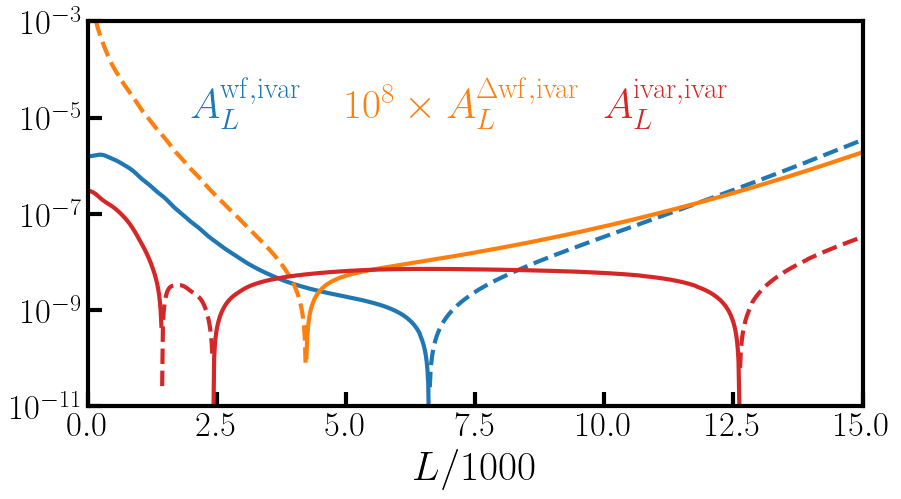

In [11]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
ax.tick_params(direction='in')

I = np.where(Nt*(At-Ak)>0)
ax.plot(L[I]/1e3,(Nt*(At-Ak))[I],lw=3,c='C0')
I = np.where(Nt*(At-Ak)<0)
ax.plot(L[I]/1e3,-1*(Nt*(At-Ak))[I],lw=3,c='C0',ls='--')
#
I = np.where(Nt*Ak/(L)**2>0)
ax.plot(L[I]/1e3,1e8*(Nt*Ak/(L)**2)[I],lw=3,c='C1')
I = np.where(Nt*Ak/(L)**2<0)
ax.plot(L[I]/1e3,-1e8*(Nt*Ak/(L)**2)[I],lw=3,c='C1',ls='--')
#
I = np.where((Nt*As>0)*(L<2000))
ax.plot(L[I]/1e3,(Nt*As)[I],lw=3,c='C3')
I = np.where((Nt*As>0)*(L>2000))
ax.plot(L[I]/1e3,(Nt*As)[I],lw=3,c='C3')
I = np.where((Nt*As<0)*(L<5000))
ax.plot(L[I]/1e3,-1*(Nt*As)[I],lw=3,c='C3',ls='--')
I = np.where((Nt*As<0)*(L>5000))
ax.plot(L[I]/1e3,-1*(Nt*As)[I],lw=3,c='C3',ls='--')

ax.text(2,1e-5,r'$A^{\rm wf,ivar}_L$',color='C0',fontsize=30)
ax.text(5,1e-5,r'$10^8\times A^{\Delta{\rm wf,ivar}}_L$',color='C1',fontsize=30)
ax.text(10,1e-5,r'$A^{{\rm ivar,ivar}}_L$',color='C3',fontsize=30)

plt.yscale('log')
plt.xlim(0,15)
plt.ylim(1e-11,1e-3)
plt.xlabel(r'$L/1000$')
plt.savefig('../../Downloads/bias_hardened_filters.pdf',bbox_inches='tight')

# Linear response to lensing, and the bias induced by $C^{\kappa g}_L$

In [2]:
def fk(l,L,theta):
    """linear response to kappa"""
    Lml = (L**2+l**2-2*L*l*np.cos(theta))**0.5
    res = L*l*np.cos(theta)*cmb.flensedTT(l)
    res+= L*(L-l*np.cos(theta))*cmb.flensedTT(Lml)
    return np.nan_to_num(2*res/L**2)

def ft(l,L,theta):
    """linear response to patchy screening"""
    Lml = (L**2+l**2-2*L*l*np.cos(theta))**0.5
    res = cmb.flensedTT(l) + cmb.flensedTT(Lml)
    return -1.*res

def Wl(l):
    """long (low pass) filter, from 2401.13033"""
    res = np.cos((l-2000)*np.pi/300)
    res = np.where(l<2000,np.ones_like(l) ,res)
    res = np.where(l>2150,np.zeros_like(l),res)
    return res#1.*(l<1000) #np.nan_to_num(cmb.flensedTT(l)/cmb.ftotalTT(l)) #1.*(l<1200) #res #1.*(l<2000)

def Ws(l):
    """short (high pass) filter, from 2401.13033"""
    res = np.sin((l-2350)*np.pi/300)
    res = np.where(l<2350,np.zeros_like(l),res)
    res = np.where(l>2500,np.ones_like(l) ,res)
    return res #1.*(l>1000) #np.ones_like(l) #1.*(l>=1200) ##res #1.*(l>=2000)

def beam(l,fwhm):
    """returns (map level) beam, fwhm in arcmin"""
    sigma = (fwhm/60*np.pi/180)/(8*np.log(2))**0.5
    return np.exp(-0.5*(l*sigma)**2)

def response_tau(L,fx,r,fwhm=1.6,lmax=10e3,ntheta=300):
    """Response of stacked tau estimator to fx, assuming Tl is evaluated at r_i, while T_s at r+r_i"""
    theta = np.linspace(0,2*np.pi,ntheta)
    l     = np.linspace(1,lmax,int(lmax))
    res   = np.zeros_like(theta)
    for i in range(ntheta):
        Lml    = (L**2+l**2-2*L*l*np.cos(theta[i]))**0.5
        intg   = (Lml<lmax)*beam(Lml,fwhm)*Wl(l)*Ws(Lml)*fx(l,L,theta[i])*l*jv(0,r*Lml)/(2*np.pi)**2
        res[i] = np.trapz(intg,l)
    res = -1*np.trapz(res,theta)
    res/= np.trapz(Wl(l)**2*cmb.flensedTT(l)*l/(2*np.pi),l)
    return res
    
L   = np.array( np.linspace(1,4000,60).tolist() + np.linspace(4000,14000,100).tolist() )
def tkResponse(r): return np.array([response_tau(l,fk,r,fwhm=1.6,lmax=18e3,ntheta=70) for l in L])
def ttResponse(r): return np.array([response_tau(l,ft,r,fwhm=1.6,lmax=18e3,ntheta=70) for l in L])

def rtx(lcut,L,fx,lmax=20e3,ntheta=300):
    theta = np.linspace(0,2*np.pi,ntheta)
    l     = np.linspace(1,lmax,int(lmax))
    res   = np.zeros_like(theta)
    for i in range(ntheta):
        Lml    = (L**2+l**2-2*L*l*np.cos(theta[i]))**0.5
        intg   = (Lml<lmax)*fx(l,L,theta[i])*l/(2*np.pi)**2
        intg  *= (l<lcut)*(Lml>lcut)
        res[i] = np.trapz(intg,l)
    res = np.trapz(res,theta)
    return res

def rtk(lc): return np.array([rtx(lc,l,fk) for l in L])
def rtt(lc): return np.array([rtx(lc,l,ft) for l in L])

In [ ]:
pool = mp.Pool(processes=(ncpu-1))
r    = np.linspace(0,11,45)
Rtk  = pool.map(tkResponse,r/60*np.pi/180) ; print('Finished with Rtk, working on Rtt')
Rtt  = pool.map(ttResponse,r/60*np.pi/180)
pool.close()
#
fname  = 'tau-resp-to-kappa_diff-pos_coulton-filters_beam-1.6_lmax-18000.txt'
header = 'To compute the bias at radius r, apply the (response) filter R^{tk}_L(r) to a\n' 
header+= 'convergence map and compute the average value of the filtered map evaluated at\n' 
header+= 'each galaxy position.\n\n'
header+= 'columns are: L '
for rr in r: header+='R^{tk}_L(r='+str(np.round(rr,2))+') '
np.savetxt(fname,np.array([list(L)]+Rtk).T,header=header)
fname  = 'tau-resp-to-kappa_same-pos_coulton-filters_beam-1.6_lmax-18000.txt'
Rtk_   = [jv(0,L*rr/60*np.pi/180)*Rtk[0] for rr in r]
np.savetxt(fname,np.array([list(L)]+Rtk_).T,header=header)

###########################################

fname  = 'tau-resp-to-tau_diff-pos_coulton-filters_beam-1.6_lmax-18000.txt'
header = 'columns are: L '
for rr in r: header+='R^{tt}_L(r='+str(np.round(rr,2))+') '
np.savetxt(fname,np.array([list(L)]+Rtt).T,header=header)
fname  = 'tau-resp-to-tau_same-pos_coulton-filters_beam-1.6_lmax-18000.txt'
Rtt_   = [jv(0,L*rr/60*np.pi/180)*Rtt[0] for rr in r]
np.savetxt(fname,np.array([list(L)]+Rtt_).T,header=header)

In [3]:
r    = np.linspace(0,11,45)
dat = np.loadtxt('tau-resp-to-kappa_diff-pos_coulton-filters_beam-1.4_lmax-18000.txt').T
L   = dat[0]
Rtk = dat[1:]
dat = np.loadtxt('tau-resp-to-kappa_same-pos_coulton-filters_beam-1.4_lmax-18000.txt').T
L   = dat[0]
Rtk_= dat[1:]

########

dat = np.loadtxt('tau-resp-to-tau_diff-pos_coulton-filters_beam-1.4_lmax-18000.txt').T
L   = dat[0]
Rtt = dat[1:]
dat = np.loadtxt('tau-resp-to-tau_same-pos_coulton-filters_beam-1.4_lmax-18000.txt').T
L   = dat[0]
Rtt_= dat[1:]

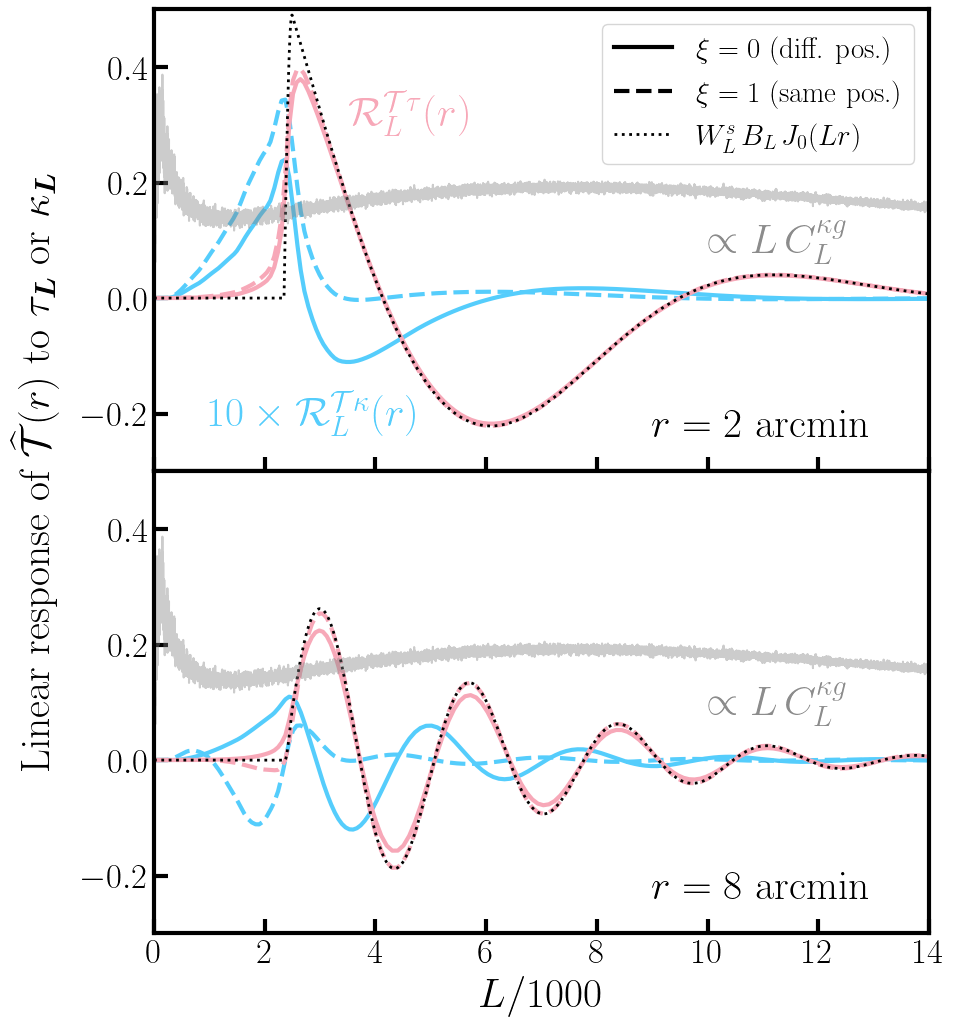

In [4]:
fig,ax = plt.subplots(2,1,figsize=(10,12),sharex=True)
ax[0].tick_params(direction='in')
ax[1].tick_params(direction='in')

blue = rgb_to_mpl_color(85 , 205, 252) # Maya Blue
pink = rgb_to_mpl_color(247, 168, 184) # Amaranth Pink

ax[0].plot([],[],c='k',lw=3,        label=r'$\xi=0$ (diff. pos.)')
ax[0].plot([],[],c='k',lw=3,ls='--',label=r'$\xi=1$ (same  pos.)')

LLL = np.linspace(1,14e3,int(14e3))
#
ax[0].plot(LLL/1e3,np.interp(LLL,L,10*Rtk[8]),c=blue,lw=3)
ax[0].plot(LLL/1e3,np.interp(LLL,L,10*Rtk[0]*jv(0,L*r[8]/60*np.pi/180)),c=blue,ls='--',lw=3)
ax[0].plot(LLL/1e3,np.interp(LLL,L,Rtt[8]),c=pink,lw=3)
ax[0].plot(LLL/1e3,np.interp(LLL,L,Rtt[0]*jv(0,L*r[8]/60*np.pi/180)),c=pink,ls='--',lw=3)
#
ax[1].plot(LLL/1e3,np.interp(LLL,L,10*Rtk[32]),c=blue,lw=3)
ax[1].plot(LLL/1e3,np.interp(LLL,L,10*Rtk[0]*jv(0,L*r[32]/60*np.pi/180)),c=blue,ls='--',lw=3)
ax[1].plot(LLL/1e3,np.interp(LLL,L,Rtt[32]),c=pink,lw=3)
ax[1].plot(LLL/1e3,np.interp(LLL,L,Rtt[0]*jv(0,L*r[32]/60*np.pi/180)),c=pink,ls='--',lw=3)
# bessel functions
ax[0].plot(LLL/1e3,jv(0,LLL*2/60*np.pi/180)*beam(LLL,fwhm=1.4)*Ws(LLL),color='k',lw=2,ls='dotted',label=r'$W^s_L\, B_L\, J_0(L r)$')
ax[1].plot(LLL/1e3,jv(0,LLL*8/60*np.pi/180)*beam(LLL,fwhm=1.4)*Ws(LLL),color='k',lw=2,ls='dotted')
# l ckg
ckg = np.load("../../Downloads/C_ell_halos_6.e12_kappa_8192_ph201.npy")
l   = np.arange(len(ckg)).astype(np.float32)

ax[0].plot(LLL/1e3,np.interp(LLL,l,7e3*ckg*l),color='grey',alpha=0.4)
ax[0].text(10,0.08,r'$\propto L\,C^{\kappa g}_L$',fontsize=30,color='grey',alpha=0.9)
ax[1].plot(LLL/1e3,np.interp(LLL,l,7e3*ckg*l),color='grey',alpha=0.4)
ax[1].text(10,0.08,r'$\propto L\,C^{\kappa g}_L$',fontsize=30,color='grey',alpha=0.9)


#l,ckg=np.loadtxt('../../Downloads/ckg_bg.txt').T
#ax[0].plot(LLL/1e3,np.interp(LLL,l,7e3*ckg*l),color='grey',lw=3)
#ax[1].plot(LLL/1e3,np.interp(LLL,l,7e3*ckg*l),color='grey',lw=3)

#ax[1].plot(LLL/1e3,LLL/45e3,color='C7',alpha=1,lw=2)
#ax[1].text(11,0.3,r'$\boldsymbol{\propto L}$',color='C7')

ax[1].set_xlabel(r'$L/1000$')
ax[1].set_xlim(0,14)
ax[1].set_yscale('linear')
ax[0].legend(loc='upper right',frameon=True,fontsize=21,framealpha=0.8)
for i in range(2): ax[i].set_ylim(-0.3,0.5)
ax[0].text(9,-0.24,r'$r=2$ arcmin',fontsize=30)
ax[1].text(9,-0.24,r'$r=8$ arcmin',fontsize=30)
ax[0].text(3.5,0.3,r'${\mathcal{R}}^{\mathcal{T}\tau}_L(r)$',color=pink,fontsize=30)
ax[0].text(1,-0.22,r'$10\times {\mathcal{R}}^{\mathcal{T}\kappa}_L(r)$',color=blue,fontsize=30)
plt.text(-2.6,0.,r'Linear response of $\widehat{\mathcal{T}}(r)$ to $\tau_{\boldsymbol{L}}$ or $\kappa_{\boldsymbol{L}}$',rotation=90,fontsize=30)
fig.subplots_adjust(hspace=0.)
plt.savefig('../../Downloads/rtk_rtt.pdf',bbox_inches='tight')

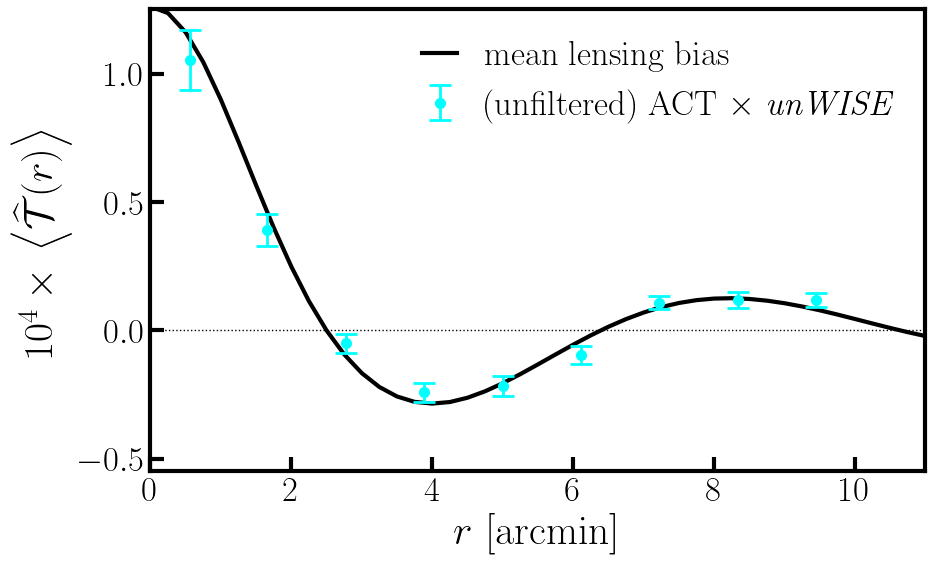

In [5]:
#plt.figure(figsize=(8,6))

fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.tick_params(direction='in')

ksz=np.array([[0.6551724137931032, 0.00003510638297872341],
[1.767241379310346, 0.000009574468085106388],
[2.892241379310345, -0.000005319148936170194],
[3.9913793103448274, -0.000007446808510638278],
[5.10344827586207, -0.000002765957446808473],
[6.2155172413793105, 2.1276595744683271e-7],
[7.3275862068965525, 0.0000014893617021276935],
[8.439655172413794, 0.0000027659574468085],
[9.551724137931036, 0.0000014893617021276935]])

#plt.plot(ksz[:,0],1e4*ksz[:,1],c='r',alpha=0.7,ls='--',lw=2,label=r'$\simeq$ expected signal')

# Rtk should be modified to match beam, etc from Will's paper

# switch from 1.4 to 1.6 arcmin just for this plot
r    = np.linspace(0,11,45)
dat = np.loadtxt('tau-resp-to-kappa_diff-pos_coulton-filters_beam-1.6_lmax-18000.txt').T
L   = dat[0]
Rtk = dat[1:]

l,ckg=np.loadtxt('../../Downloads/ckg_bg.txt').T # unwise blue+green cross-correlation
def from_Rtk_to_B(Rtk):
    integrand = Rtk*L*np.interp(L,l,ckg)/(2*np.pi)
    return np.trapz(integrand,L)
B = np.array([from_Rtk_to_B(rtk) for rtk in Rtk])
R = np.linspace(0,11,45)
plt.plot(R,1e4*B,c='k',lw=3,label=r'mean lensing bias')

# okay now I'm done so switch back to 1.4
r    = np.linspace(0,11,45)
dat = np.loadtxt('tau-resp-to-kappa_diff-pos_coulton-filters_beam-1.4_lmax-18000.txt').T
L   = dat[0]
Rtk = dat[1:]

# Will's mean field
#plt.plot(mean_field[:,0],mean_field[:,1],marker='.',markersize=10,ls='--',color='k',label='mean field')

# Will's data
sigma = coulton_measurement[:,2]-coulton_measurement[:,1]
plt.errorbar(coulton_measurement[:,0],coulton_measurement[:,1],yerr=sigma,color='cyan',
             marker='.',lw=2,ls='',capsize=8,capthick=3,markersize=12,markeredgewidth=2,label=r'(unfiltered) ACT $\times$ \textit{unWISE}')

# bin the lensing 
rbin_edges = np.linspace(0,10,10)
lensing_contribution = np.zeros(9)
for i in range(9): lensing_contribution[i] = np.trapz((R>=rbin_edges[i])*(R<rbin_edges[i+1])*R*B,R)/np.trapz((R>=rbin_edges[i])*(R<rbin_edges[i+1])*R,R)

# Will's data corrected
#plt.errorbar(coulton_measurement[:,0],coulton_measurement[:,1]-1e4*lensing_contribution,yerr=coulton_measurement[:,2]-coulton_measurement[:,1],
#             color='C2',marker='.',lw=2,ls='',capsize=8,capthick=3,markersize=12,markeredgewidth=2,label='lensing corrected profile')

#plt.text(3,0.3,r'$\chi^2_{\rm null} = 90\,\,(7.9\sigma)$',color='C1')
#plt.text(0.5,-0.4,r'$\chi^2_{\rm null} = 11\,\,(0.5\sigma)$',color='C2')

plt.legend(loc='upper right',frameon=False,fontsize=25,handlelength=1)
plt.axhline(y=0,c='k',lw=1,ls='dotted') 
plt.ylabel(r'$10^4\times\,\big\langle\widehat{\mathcal{T}}(r)\big\rangle$',fontsize=30)
plt.xlabel(r'$r$ [arcmin]')
plt.xlim(0,11)
plt.ylim(-0.55,1.25)
plt.savefig('../../Downloads/unwise_bias.pdf',bbox_inches='tight')

In [10]:
dat = np.loadtxt('tau-resp-to-tau_diff-pos_coulton-filters_beam-1.6_lmax-18000.txt').T
L   = dat[0]
Rtt = dat[1:]
r   = np.linspace(0,11,45)
rp  = np.linspace(0,50,500)
Lint= np.logspace(np.log10(min(L)),np.log10(max(L)),5000)
FWHM=2
sigma= FWHM/(8*np.log(2))**0.5
profile = np.exp(-rp**2/2/sigma**2)#(1+rp/2)**-0.29
ft  = np.array([np.trapz(rp/60*np.pi/180*profile*jv(0,L*rp/60*np.pi/180),x=rp/60*np.pi/180) for L in Lint])
convolved_profile = np.array([np.trapz(np.interp(Lint,L,Rtt[i,:])*Lint*ft*jv(0,rr/60*np.pi/180*Lint),x=Lint) for i,rr in enumerate(r)])
def thy(t0):
    rint=r.copy()
    rbin_edges = np.linspace(0,10,10)
    thy_smooth = 1e4*t0*convolved_profile
    thy = np.zeros(9)
    for i in range(9): thy[i] = np.trapz((rint>=rbin_edges[i])*(rint<rbin_edges[i+1])*rint*thy_smooth,rint)/np.trapz((rint>=rbin_edges[i])*(rint<rbin_edges[i+1])*rint,rint)
    return thy

In [15]:
fid = coulton_measurement[:,1]
cor = coulton_measurement[:,1]-1e4*lensing_contribution
corm= corrmat.copy()
corm[np.where(corm==0)]=0.2
cov = np.outer(sigma,sigma)*(0.6*corm[::-1][:9,:9]+0.4*corm[::-1][9:18,9:18])*1.101
chi2_fid = np.dot(np.dot(fid,np.linalg.inv(cov)),fid)
chi2_cor = np.dot(np.dot(cor,np.linalg.inv(cov)),cor)

print(chi2_fid,chi2_cor)

from scipy.stats import chi2
from scipy.special import erf

1-chi2.cdf(chi2_fid,9),1-chi2.cdf(chi2_cor,9)

4.75315437138143 0.03526526965615652


(0.8552736910174225, 0.9999999997582832)

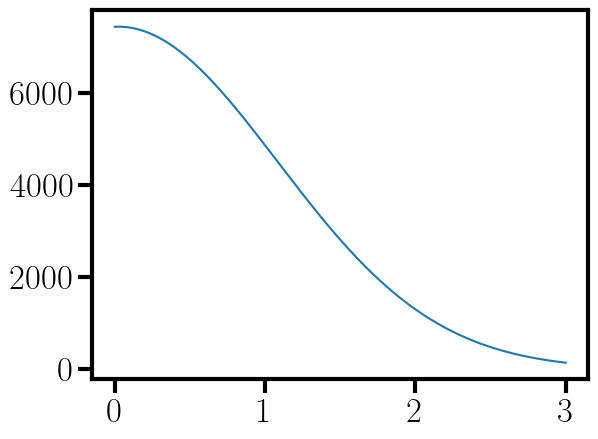

In [16]:
def chi2(t0): return np.dot(np.dot(thy(t0)-cor,np.linalg.inv(cov)),thy(t0)-cor)
t0 = np.linspace(0,0.3e-3,500)
L  = np.array([np.exp(-chi2(tt)/2) for tt in t0])
L/=np.trapz(L,x=t0)
plt.plot(10**4*t0,L)

In [21]:
np.trapz(L*(t0<1.06e-4),t0)

0.6819155849190189

In [28]:
ckg = np.load("../../Downloads/C_ell_halos_6.e12_kappa_8192_ph201.npy")
l   = np.arange(len(ckg)).astype(np.float32)
def from_Rtk_to_B(Rtk,Lmax=18e3):
    integrand = (L<Lmax)*Rtk*L*np.interp(L,l,ckg)/(2*np.pi)
    return np.trapz(integrand,L)

B = np.array([from_Rtk_to_B(rtk) for rtk in Rtk])
B_= np.array([from_Rtk_to_B(Rtk[0]*jv(0,rr*L/60*np.pi/180)) for rr in r])
R = np.linspace(min(r),max(r),200)
B = np.interp(R,r,B)
B_= np.interp(R,r,B_)

['prof_mean', 'prof_err', 'm_mean']
['prof_mean', 'prof_err', 'm_mean']
['prof_mean', 'prof_err', 'm_mean']
['prof_mean', 'prof_err', 'm_mean']


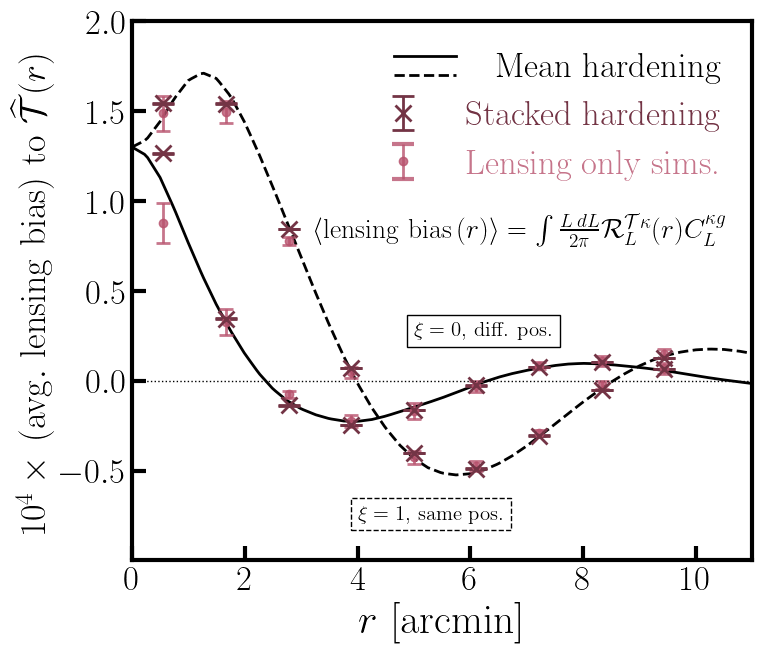

In [30]:
sim_color       = rgb_to_mpl_color(115, 52, 69) # color name is Catawba
sim_color_faded = rgb_to_mpl_color(115*1.6, 52*1.6, 69*1.6)

plt.figure(figsize=(8,7))
plt.tick_params(direction='in')

plt.plot(R,1e4*B ,c='k',lw=2)
plt.plot(R,1e4*B_,c='k',lw=2,ls='--')
plt.errorbar([10],[10],yerr=[1],color=sim_color,marker='x',lw=2,ls='',capsize=8,capthick=3,markersize=12,markeredgewidth=2,label=r'Stacked hardening')
plt.errorbar([10],[10],yerr=[1],color=sim_color_faded,capsize=8,capthick=3,marker='o',lw=2,ls='',label=r'Lensing only sims.',alpha=0.8)

#plt.
rsim = np.linspace(0,10,10)
rsim = (rsim[1:]+rsim[:-1])/2.
#plt.errorbar(rsim,np.interp(rsim,R,1e4*B) ,yerr=np.abs(np.interp(rsim,R,1e4*B)*0.1) ,color=sim_color,capsize=6,capthick=3,marker='o',lw=3,ls='')
#plt.errorbar(rsim,np.interp(rsim,R,1e4*B_),yerr=np.abs(np.interp(rsim,R,1e4*B_)*0.1),color=sim_color,capsize=6,capthick=3,marker='o',lw=3,ls='')
#plt.errorbar(rsim,np.interp(rsim,R,1e4*B) ,yerr=np.abs(np.interp(rsim,R,1e4*B)*0.1),color=sim_color,marker='x',lw=2,ls='',capsize=5,capthick=3,markersize=12,markeredgewidth=2)
#plt.errorbar(rsim,np.interp(rsim,R,1e4*B_) ,yerr=np.abs(np.interp(rsim,R,1e4*B_)*0.1),color=sim_color,marker='x',lw=2,ls='',capsize=5,capthick=3,markersize=12,markeredgewidth=2)
#

# sign and 40 muK cut, diff pos.
m_str = "logm13.07_m1.17e+13"
fwhm_str = "fwhm1.4"
data = np.load(f"../../Downloads/extended_lrg_notau_lensed_{m_str}_{fwhm_str}.npz")
print(data.files) # to see what is in it
prof_not_len_mean = data['prof_mean']
prof_not_len_err = data['prof_err']
plt.errorbar(rsim,1e4*prof_not_len_mean,yerr=1e4*prof_not_len_err,color=sim_color_faded,capsize=5,capthick=2,marker='o',lw=2,ls='',alpha=0.8)

# 40 cut at r_i, T_l * T_s at the same position
m_str = "logm13.07_m1.17e+13"
fwhm_str = "fwhm1.4"
data = np.load(f"../../Downloads/test_no40uK_extended_lrg_notau_lensed_{m_str}_{fwhm_str}.npz")
print(data.files) # to see what is in it
prof_not_len_mean = data['prof_mean']
prof_not_len_err = data['prof_err']
plt.errorbar(rsim,1e4*prof_not_len_mean,yerr=1e4*prof_not_len_err,color=sim_color_faded,capsize=5,capthick=2,marker='o',lw=2,ls='',alpha=0.8)

# stacked hardening
data = np.load(f"../../Downloads/kappa_extended_lrg_notau_lensed_logm13.07_m1.17e+13_fwhm1.4.npz")
print(data.files) # to see what is in it
prof_not_len_mean = data['prof_mean']
prof_not_len_err = data['prof_err']
plt.errorbar(rsim,1e4*prof_not_len_mean,yerr=1e4*prof_not_len_err,color=sim_color,marker='x',lw=2,ls='',capsize=8,capthick=3,markersize=12,markeredgewidth=2)


data = np.load(f"../../Downloads/kappa_same_extended_lrg_notau_lensed_logm13.07_m1.17e+13_fwhm1.4.npz")
print(data.files) # to see what is in it
prof_not_len_mean = data['prof_mean']
prof_not_len_err = data['prof_err']
plt.errorbar(rsim,1e4*prof_not_len_mean,yerr=1e4*prof_not_len_err,color=sim_color,marker='x',lw=2,ls='',capsize=8,capthick=3,markersize=12,markeredgewidth=2)

#plt.errorbar(rsim,np.interp(rsim,R,1e4*B_) ,yerr=np.abs(np.interp(rsim,R,1e4*B_)*0.1) ,color=sim_color_faded,capsize=5,capthick=2,marker='o',lw=2,ls='',alpha=0.8)

plt.axhline(y=0,c='k',lw=1,ls='dotted') 
plt.xlim(0,11)
leg = plt.legend(loc='upper right',frameon=False,fontsize=25,labelcolor='linecolor',title='Mean hardening',title_fontsize=25)
plt.plot([4.65,5.75],[1.81,1.81],c='k',lw=2)
plt.plot([4.65,5.75],[1.7,1.7],c='k',lw=2,ls='--')
leg._legend_box.align = "right"
#plt.text(0.3,-0.8,r'$\boldsymbol{10^4\times\,{\rm Lensing\,\,Bias}\Big[\langle\hat{\mathcal{T}}(r)\rangle\Big]} $',fontsize=24)
plt.ylabel(r'$10^4\times\,{\rm (avg.\,\,lensing\,\,bias)\,\,to\,\,}\widehat{\mathcal{T}}(r)$',fontsize=26)
plt.xlabel(r'$r$ [arcmin]')
plt.ylim(-1.,2)
plt.yticks([-0.5,0,0.5,1,1.5,2])

t = plt.text(5,0.25,r'$\xi=0$, diff. pos.',fontsize=15)
t.set_bbox(dict(alpha=1,facecolor='white',edgecolor='k',pad=5,lw=1))
t = plt.text(4,-0.77,r'$\xi=1$, same  pos.',fontsize=15)
t.set_bbox(dict(alpha=1,facecolor='white',edgecolor='k',pad=5,ls='--',lw=1))
plt.xticks([0,2,4,6,8,10])
t = plt.text(3.25,0.8,r'$\langle{\rm lensing\,\,bias\,}(r)\rangle = \int \frac{L\,dL}{2\pi} {\mathcal{R}}^{\mathcal{T}\kappa}_L(r) C^{\kappa g}_L$', fontsize=20)
t.set_bbox(dict(facecolor='white', alpha=1,edgecolor='w',lw=2,pad=8)) #rgb_to_mpl_color(234,234,234)
plt.savefig('../../Downloads/avg_bias.pdf',bbox_inches='tight')

# Covariance

In [126]:
L                       = np.linspace(1,15e3,1000)
Rtt,Rkk,Rss,Rtk,Rts,Rks = [Rxy[:,i].copy() for i in range(6)]
Nt                      = 1/Rtt
Tlsq                    = np.trapz(Wl(L)**2*np.nan_to_num(cmb.ftotalTT(L))*L/(2*np.pi),L)

### How to compute the signal, assume $C^{\tau g}_\ell = 1$

$$
R^{\tau\tau}_L(r) = J_0(L r) 
$$

$$
\mathcal{R}^{\mathcal{T}\tau}_L(r)
=
\frac{1}{\langle T_l^2\rangle}
\int_\ell
J_0(|L-\ell|r)
W^l_\ell W^s_{L-\ell}
(C_\ell + C_{L-\ell})
$$

$$
\mathcal{T}(r_1,r_2)
=
\int \frac{L\,dL}{2\pi}
C^{\tau g}_L
\int_{r_1}^{r_2}\frac{2r\, dr}{r_2^2-r_1^2}
R^{\mathcal{T}\tau}_L(r)
$$

In [128]:
def fancyRfancyTt(L,lmax=10e3,ntheta=500):
    theta = np.linspace(0,2*np.pi,ntheta)
    l     = np.linspace(1,lmax,int(lmax))
    res   = np.zeros_like(theta)
    for i in range(ntheta):
        Lml    = (L**2+l**2-2*L*l*np.cos(theta[i]))**0.5
        intg   = -1*(Lml<lmax)*Wl(l)*Ws(Lml)*ft(l,L,theta[i])*l/(2*np.pi)**2/Tlsq
        res[i] = np.trapz(intg,l)
    return np.trapz(res,theta)

In [136]:
RRTt = np.array([fancyRfancyTt(LL) for LL in L])

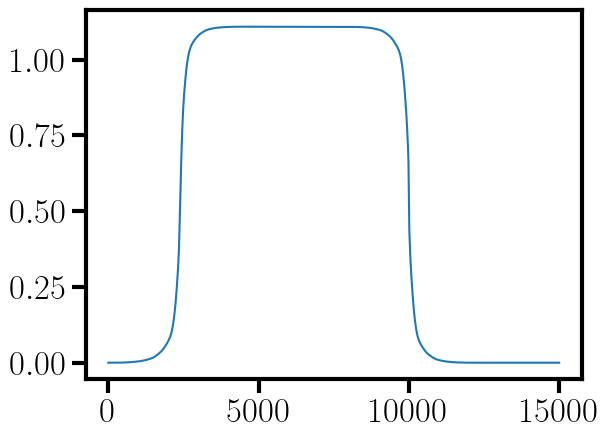

In [137]:
plt.plot(L,RRTt)

(0.9, 1.1)

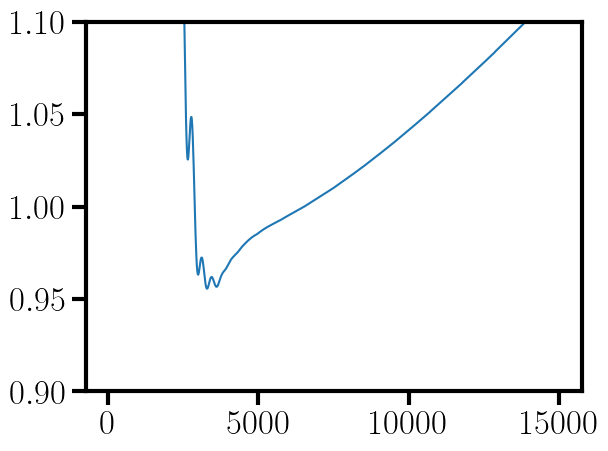

In [116]:
plt.plot(L,Rtt*cmb.ftotalTT(L)/Tlsq)
plt.ylim(0.9,1.1)

# Bispectrum bias

In [13]:
def Kn(l,llist):
    """
    l: (2,) ndarray
    llist: list of (2,) ndarray's
    """
    n   = len(llist)
    res = (-2)**n/factorial(n)
    L   = np.zeros_like(l)
    for i in range(n): L   += llist[i]
    for i in range(n): res *= np.dot(llist[i],l-L)/np.dot(llist[i],llist[i])
    return res

def f2(l1,l2,l3):
    """
    li: (2,) ndarray
    """
    l1ml3 = np.dot(l1-l3,l1-l3)**0.5
    l2ml3 = np.dot(l2-l3,l2-l3)**0.5
    res   = Kn(l1,[l1+l2-l3,l3])*cmb.flensedTT(np.dot(l2,l2)**0.5)
    res  += Kn(l2,[l1+l2-l3,l3])*cmb.flensedTT(np.dot(l1,l1)**0.5)
    res  += 0.5*Kn(l1,[l3])*Kn(l2,[l1+l2-l3])*cmb.flensedTT(l1ml3)
    res  += 0.5*Kn(l2,[l3])*Kn(l1,[l1+l2-l3])*cmb.flensedTT(l2ml3)
    return res

In [14]:
l = np.array([3000,0])
L = np.array([100,0])

theta = np.linspace(0,2*np.pi,20)
iii    = np.array([f2(l,L-l, 2000*np.array([np.cos(t),np.sin(t)])  ) for t in theta])

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

In [11]:
[2000*np.array([np.cos(t),np.sin(t)]) for t in theta]

[array([2000.,    0.]),
 array([1891.6344834 ,  649.39893841]),
 array([1578.28101879, 1228.42542538]),
 array([1093.89631624, 1674.33295653]),
 array([ 490.97097428, 1938.80053188]),
 array([-165.15869094, 1993.16898601]),
 array([-803.39084931, 1831.54665331]),
 array([-1354.56314325,  1471.44782135]),
 array([-1758.94750241,   951.89478607]),
 array([-1972.72260681,   329.18918056]),
 array([-1972.72260681,  -329.18918056]),
 array([-1758.94750241,  -951.89478607]),
 array([-1354.56314325, -1471.44782135]),
 array([ -803.39084931, -1831.54665331]),
 array([ -165.15869094, -1993.16898601]),
 array([  490.97097428, -1938.80053188]),
 array([ 1093.89631624, -1674.33295653]),
 array([ 1578.28101879, -1228.42542538]),
 array([1891.6344834 , -649.39893841]),
 array([ 2.0000000e+03, -4.8985872e-13])]

# Linear responses

In [2]:
def get_beam(l,theta=1.6): return np.exp(-0.5*((theta*np.pi/180/60)*l)**2/(8*np.log(2)))

def get_pixwin(l,theta=0.25/60*np.pi/180): return np.sin((l+1e-4)*theta/2)/((l+1e-4)*theta/2)

def Wlow_(l):
    # the low-pass filter has been beam deconvolved
    if l<2000: return 1.
    if l>2150: return 0.
    return np.cos((l-2000.)*np.pi/300.)

def Whi_(l,theta=1.6,lc=12000):
    if l>lc: return 0.
    if l>2500: return get_beam(l)
    if l<2350: return 0.
    return np.sin((l-2350.)*np.pi/300.)*get_beam(l,theta=theta)

Wlow = lambda l: np.vectorize(Wlow_)(l)

def Whi(l,theta,lc):
    return np.array([Whi_(q,theta,lc) for q in l])

#Whi  = lambda l,theta,lc: np.vectorize(lambda q: Whi_(q,theta,lc))(l)

def I(L,l,ntheta=300,theta=1.6,lc=12000):
    Theta = np.linspace(0,2*np.pi,ntheta)
    Wlow_l = Wlow(l)
    Whi_l  = Whi(l*np.ones_like(Theta),theta,lc)
    Wlow_Ll= Wlow((L**2+l**2-2*L*l*np.cos(Theta))**0.5)
    Whi_Ll = Whi((L**2+l**2-2*L*l*np.cos(Theta))**0.5,theta,lc)
    integrand = Wlow_l*Whi_Ll + Wlow_Ll*Whi_l
    integrand*= 2*cmb.funlensedTT(l)*L*l**2*np.cos(Theta)/(2*np.pi)**2/L**2
    return simps(integrand,Theta)

def J(L,l,ntheta=300,theta=1.6,lc=12000):
    Theta = np.linspace(0,2*np.pi,ntheta)
    Wlow_l = Wlow(l)
    Whi_l  = Whi(l*np.ones_like(Theta),theta,lc)
    Wlow_Ll= Wlow((L**2+l**2-2*L*l*np.cos(Theta))**0.5)
    Whi_Ll = Whi((L**2+l**2-2*L*l*np.cos(Theta))**0.5,theta,lc)
    integrand = Wlow_l*Whi_Ll + Wlow_Ll*Whi_l
    integrand*= cmb.flensedTT(l)*l/(2*np.pi)**2
    return np.trapz(integrand,Theta)

def Fphi(L,lmax=14000,nl=1000,ntheta=100,theta=1.6,lc=12000):
    l = np.linspace(1,lmax,nl)
    integrand = np.array([I(L,ll,ntheta=ntheta,theta=theta,lc=lc) for ll in l])
    return simps(integrand,l)

def Ftau(L,lmax=14000,nl=1000,ntheta=100,theta=1.6,lc=12000):
    l = np.linspace(1,lmax,nl)
    integrand = np.array([-1.*J(L,ll,ntheta=ntheta,theta=theta,lc=lc) for ll in l])
    return np.trapz(integrand,l)

In [3]:
ll = np.linspace(1,3000,500000)
tlsq = simps(ll*Wlow(ll)**2*cmb.flensedTT(ll)/(2*np.pi),ll)
print('<T_l^2> =',np.round(tlsq**0.5,2))

def load_filters(theta,lc):
    try:
        LL,FF = np.loadtxt(f'kappa_bias_filter_thetab-{theta}_lc-{lc}.txt').T
        ll,ff = np.loadtxt(f'tau_bias_filter_thetab-{theta}_lc-{lc}.txt').T
    except:
        L = np.linspace(1,15000+1,500)
        F = [-1*Fphi(LL,theta=theta,lc=lc)/tlsq for LL in L]
        LL = np.arange(1,np.max(L))
        FF = np.interp(LL,L,F)
        LL = np.array([0]+LL.tolist())
        FF = np.array([0]+FF.tolist())
        np.savetxt(f'kappa_bias_filter_thetab-{theta}_lc-{lc}.txt',np.array([LL,FF]).T,header="L, kappa filter")
        ll = np.linspace(1,np.max(L),500)
        ff = [-1*Ftau(LL,theta=theta,lc=lc)/tlsq for LL in ll]
        np.savetxt(f'tau_bias_filter_thetab-{theta}_lc-{lc}.txt',np.array([ll,ff]).T,header="L, tau filter")
    return LL,FF,ll,ff

<T_l^2> = 112.87


In [4]:
LL,FF,ll,ff = load_filters(1.6,12000)

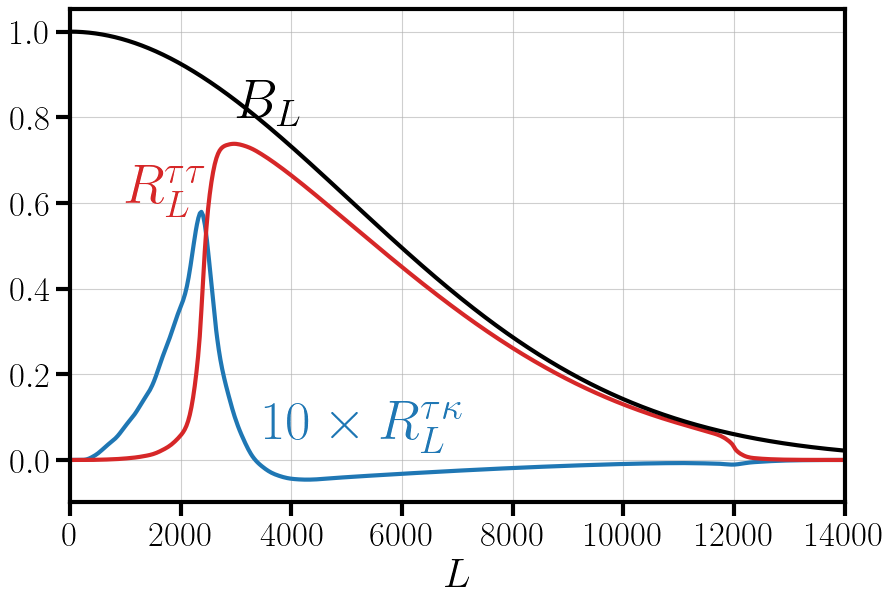

In [5]:
plt.figure(figsize=(10,6.4))
Lk,Fk,Lt,Ft = load_filters(1.6,12000)
plt.plot(Lk,1e1*Fk,c='C0',lw=3)
plt.plot(Lt,Ft,c='C3',lw=3)
plt.plot(Lk,get_beam(Lk,theta=1.6),c='k',lw=3)
plt.xlabel(r'$L$')
plt.xlim(0,14000)
plt.yscale('linear')
plt.grid(alpha=0.6,which='major')
plt.grid(alpha=0.1,which='minor')
plt.text(3500,0.05,r'$10\times R^{\tau\kappa}_L$',color='C0',fontsize=40)
plt.text(1000,0.6,r'$R^{\tau\tau}_L$',color='C3',fontsize=40)
plt.text(3000,0.8,r'$B_L$',fontsize=40)
plt.savefig('../../Downloads/phi_filter.pdf',bbox_inches='tight')

In [6]:
l,ckg0 = np.loadtxt('../../Downloads/lrg_extended_ckg_power_law.txt').T
ckg1   = ckg0/(1+(l/5000))**2

def get_lensing_bias(LL,FF,l=l,ckg=ckg0):
    ckg = np.interp(LL,l,ckg)
    Br  = lambda r: simps(jv(0,r*LL)*LL*FF*ckg/(2*np.pi),LL)
    r = np.linspace(0.01,11,200)*np.pi/60/180 # radians
    B = [Br(rr) for rr in r]
    return r,B

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


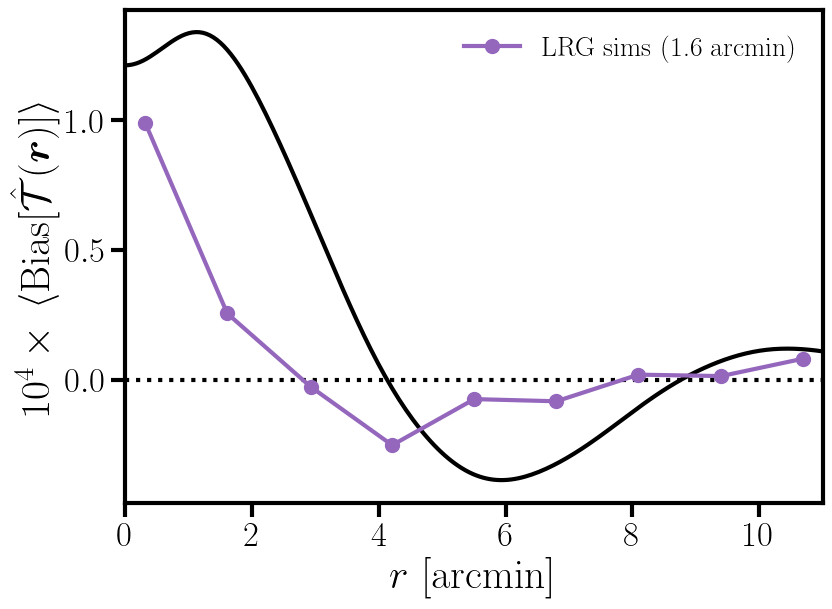

In [7]:
plt.figure(figsize=(9,6.4))

ckg1   = ckg0/(1+(l/10000))**2

Lk,Fk,Lt,Ft = load_filters(1.6,12000)
r,B  = get_lensing_bias(Lk,Fk,ckg=ckg0)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',lw=3)

#r,B  = get_lensing_bias(Lk,np.roll(Fk,1000),ckg=np.roll(ckg1,0))
#plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',ls='--',lw=3)

plt.legend(loc='upper right',frameon=False,fontsize=27,title=r'$\theta_{\rm FWHM} = 1.6\,\,{\rm arcmin}$')

#plt.scatter(Coulton[:,0],Coulton[:,1],c='C3',s=30,label=r'unWISE Blue+Green')

#plt.errorbar(lrg_mean[:,0],1e4*lrg_mean[:,1],yerr=1e4*np.array([lrg_mean[:,1]-lrg_lo[:,1],lrg_hi[:,1]-lrg_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'kSZ + lensing, DESI extended LRGs',color='C4')

#plt.errorbar(unwise_mean[:,0],unwise_mean[:,1],yerr=np.array([unwise_mean[:,1]-unwise_lo[:,1],unwise_hi[:,1]-unwise_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'$\textit{unWISE}$ Green and Blue',color='C6')


#plt.plot([],[],lw=3,c='k',label=r'Expected lensing bias from $C^{\kappa g}_L$')

plt.errorbar(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),c='C4',
             markersize=10,marker='o',lw=3,ls='-',label='LRG sims (1.6 arcmin)')

plt.axhline(y=0,c='k',lw=3,ls='dotted')
plt.legend(fontsize=20,frameon=False)
plt.xlim(0,11)
plt.ylabel(r'$10^4\times\,\langle {\rm Bias}[\hat{\mathcal{T}}(\boldsymbol{r})] \rangle$')
plt.xlabel(r'$r$ [arcmin]')
plt.savefig('../../Downloads/avg_bias.pdf',bbox_inches='tight')

\begin{equation}
R^{\tau\kappa}_L = \frac{-1}{\langle T_l^2\rangle}\int_{\boldsymbol{\ell}} W^s_\ell W^l_{|\boldsymbol{L}-\boldsymbol{\ell}|} f^\kappa_{\boldsymbol{\ell},\boldsymbol{L}-\boldsymbol{\ell}}
\end{equation}

\begin{equation}
R^{\tau\kappa}_L = \frac{-1}{\langle T_l^2\rangle}\int \frac{\ell d\ell}{2\pi} W^s_\ell \int d^2 x e^{-iLx}W^l(x) \int \frac{d\theta}{2\pi}   e^{i \ell x}  f^\kappa_{\boldsymbol{\ell},\boldsymbol{L}-\boldsymbol{\ell}}
\end{equation}

If $\tau(r)$ is a point source then after filtering and convolving with the beam

$$\int_{\ell} e^{i{\ell}\cdot{r}} B_\ell W^s_\ell = \int \frac{L dL}{2\pi} J_0(L r) B_\ell W^s_\ell$$

In [ ]:
def get_val(r): return simps(jv(0,r*ll)*ll*ff/(2*np.pi),ll)
def get_val4(r): return simps(jv(0,r*ll)*ll*ff*get_beam(5.6/60*np.pi/180,ll)/(2*np.pi),ll)
def get_val2(r): return simps(jv(0,r*LL)*LL*FF*(LL+1e-2)**-1.25/(2*np.pi),LL)
def get_val3(r): return simps(jv(0,r*LL)*LL*FF/(2*np.pi),LL)

rr = np.linspace(0.,10,100)

tt = np.array([get_val(r/60*np.pi/180) for r in rr])
tt/=np.max(tt)

tt2 = np.array([get_val2(r/60*np.pi/180) for r in rr])
tt2/=np.max(tt2)

tt3 = np.array([get_val3(r/60*np.pi/180) for r in rr])
tt3/=np.max(tt3)

tt4 = np.array([get_val4(r/60*np.pi/180) for r in rr])
tt4/=np.max(tt4)

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(rr,tt,c='k',label='Point source signal')
plt.plot(rr,tt4,ls='--',c='k',label='Gaussian source')
plt.plot(rr,tt2,label=r'bias from $C^{\kappa g}_L \propto L^{-1.25}$')
plt.plot(rr,tt3,label=r'bias from $C^{\kappa g}_L \propto L^{0}$')

plt.scatter(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),color='C4',label='Lensing from sims for LRGs')

plt.plot(rr,tt2-tt3)
plt.axhline(y=0,c='k')
plt.legend(fontsize=20)
plt.xticks([2*i for i in range(6)])
plt.xticks([0.5+0.5*i for i in range(20)],minor=True)
plt.grid(which='both')

In [ ]:
l,ckg = np.loadtxt('../../Downloads/lrg_extended_ckg_power_law.txt').T
ckg0 = np.interp(LL,l,ckg)#+2e-8*np.exp(-(LL/2300)**2)
Br = lambda r: simps(jv(0,r*LL)*LL*FF*ckg/(2*np.pi),LL)

plt.figure(figsize=(10,7))

plt.loglog(LL,ckg0)
plt.loglog(LL,ckg)
plt.loglog(LL,2e-8*(LL/1000)**-1.25,ls='--')
plt.loglog(LL,np.ones_like(LL)*2e-8)

plt.ylim(1e-9,1e-5)
plt.xlim(1e1,1e4)

In [ ]:
plt.figure(figsize=(10,7))
plt.loglog(LL,ckg/ckg0)

In [ ]:
ckg[1000]

# old stuff

In [ ]:
MV_noise = baseMap.forecastTau(cmb.flensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax)
BH_noise  = baseMap.forecastTauLensHardened(cmb.flensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax)

In [ ]:
plt.semilogy(L, MV_noise(L),label=r'minimum variance')
plt.semilogy(L, BH_noise(L),label=r'lens hardened')
plt.xlim(1e3,8e3)
plt.ylim(1e-9,1e-5)
plt.xlabel(r'mode $L$')
plt.ylabel(r'Noise per mode')
plt.legend()

In [ ]:
LL = np.linspace(1.5e3,7e3)

var_MV = np.trapz(LL*MV_noise(LL),LL)
var_BH = np.trapz(LL*BH_noise(LL),LL)

print(f'Bias hardening is {np.round((var_BH/var_MV)**0.5,1)} times noisier than the minimum variance estimator')

In [ ]:
plt.figure(figsize=(8,6))
plt.loglog(l,ckg0,lw=3,c='k',ls='-')
plt.loglog(l,ckg1,lw=3,c='k',ls='--')

plt.xlim(10,10000)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\kappa g}_\ell$')

plt.figure(figsize=(9,6.4))


Lk,Fk,Lt,Ft = load_filters(1.6)
r,B  = get_lensing_bias(Lk,Fk,ckg=ckg0)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',lw=3)

r,B  = get_lensing_bias(Lk,Fk,ckg=ckg1)
plt.plot(r/(np.pi/60/180),1e4*np.array(B),c='k',ls='--',lw=3)


plt.plot([],[],lw=3,c='k',ls='-',label=r'power law $C^{\kappa g}_\ell$ extrapolation')
plt.plot([],[],lw=3,c='k',ls='--',label=r'with additional damping')
plt.legend(loc='upper right',frameon=False,fontsize=27)

#plt.scatter(Coulton[:,0],Coulton[:,1],c='C3',s=30,label=r'unWISE Blue+Green')

#plt.errorbar(lrg_mean[:,0],1e4*lrg_mean[:,1],yerr=1e4*np.array([lrg_mean[:,1]-lrg_lo[:,1],lrg_hi[:,1]-lrg_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'kSZ + lensing, DESI extended LRGs',color='C4')

#plt.errorbar(unwise_mean[:,0],unwise_mean[:,1],yerr=np.array([unwise_mean[:,1]-unwise_lo[:,1],unwise_hi[:,1]-unwise_mean[:,1]]),lw=3,ls='',markersize=6,marker='o',capsize=4,capthick=3,label=r'$\textit{unWISE}$ Green and Blue',color='C6')


#plt.plot([],[],lw=3,c='k',label=r'Expected lensing bias from $C^{\kappa g}_L$')

plt.errorbar(lrg_mean[:,0],1e4*(lrg_mean[:,1]-lrg_ksz[:,1]),c='C4',
             markersize=10,marker='o',lw=3,ls='-',label='LRG sims')

plt.axhline(y=0,c='k',lw=3,ls='dotted')
plt.legend(fontsize=20,frameon=False,title='1.6 arcmin')
plt.xlim(0,11)
plt.ylabel(r'$10^4\times\,\langle {\rm Bias}[\hat{\mathcal{T}}(\boldsymbol{r})] \rangle$')
plt.xlabel(r'$r$ [arcmin]')